In [1]:
import numpy as np
import polars as pl
from pathlib import Path

from src.models.data import fp_from_smiles
from src.models.pipeline import results_table, run_parallel_trainings, train_and_score, tune_gnn
from src.models import config as model_cfg
from src._config import PROCESSED_DATA

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(100)

/home/computer/Repositories/ml_chembl/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


polars.config.Config

In [2]:
df = pl.read_parquet(PROCESSED_DATA / "ChEMBL_processed.parquet")

In [3]:
df_temp = df.with_columns(
    pl.col("canonical_smiles").map_elements(fp_from_smiles, return_dtype=pl.Object).alias("fp")
)
df_clean = df_temp.filter(
    (pl.col("fp").is_not_null()) & 
    (pl.col("pIC50").is_not_null()) &
    (pl.col("pIC50").is_not_nan())
)
print(f"Liczba probek po czyszczeniu: {len(df_clean)}")
print(f"Odrzucono {len(df) - len(df_clean)} blednych czasteczek.")

Liczba probek po czyszczeniu: 15723
Odrzucono 0 blednych czasteczek.


In [4]:
from src.models.config import (
    EPOCHS_DEFAULT, LR_DEFAULT, BATCH_SIZE_DEFAULT, SEED_DEFAULT,
    EARLY_STOPPING_PATIENCE_DEFAULT, MIN_DELTA_DEFAULT, WEIGHT_DECAY_DEFAULT, POOLING_DEFAULT,
)

print(f"Domyslne parametry: epochs={EPOCHS_DEFAULT}, lr={LR_DEFAULT}, batch={BATCH_SIZE_DEFAULT}, "
      f"seed={SEED_DEFAULT}, patience={EARLY_STOPPING_PATIENCE_DEFAULT}, pooling={POOLING_DEFAULT}")

fp_has_nan = any(np.isnan(fp).any() for fp in df_clean["fp"])
print(f"NaN w fingerprintach: {fp_has_nan}")

Domyslne parametry: epochs=200, lr=0.0003, batch=64, seed=42, patience=15, pooling=mean
NaN w fingerprintach: False


In [5]:
MLP_SPECS = [
    {"model_type": "MLP", "split_type": "random",   "df_fp": df_clean, "log_mlflow": True, "evaluate_test": False},
    {"model_type": "MLP", "split_type": "scaffold", "df_fp": df_clean, "log_mlflow": True, "evaluate_test": False},
]
mlp_results = run_parallel_trainings(MLP_SPECS, max_workers=2)

Loaded cached model: default_24f398a6208703eb.pt | val R²=0.737 RMSE=0.674 MAE=0.485
Loaded cached model: default_e7f7c0a0effd139b.pt | val R²=0.440 RMSE=0.830 MAE=0.629


In [6]:
SUMMARY_COLS = ["model", "split", "seed", "lr", "batch_size", "weight_decay",
                "avg_train_loss", "avg_val_loss", "best_val_loss", "r2_val", "rmse_val", "mae_val", "from_cache"]

if results_table:
    df_mlp = pl.DataFrame(results_table).filter(pl.col("model") == "MLP")
    cols = [c for c in SUMMARY_COLS if c in df_mlp.columns]
    display(df_mlp.select(cols).sort("r2_val", descending=True))
else:
    print("Brak wynikow. Uruchom najpierw komorke treningowa MLP.")

model,split,seed,lr,batch_size,weight_decay,avg_train_loss,avg_val_loss,best_val_loss,r2_val,rmse_val,mae_val,from_cache
str,str,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,bool
"""MLP""","""random""",42,0.0003,64,0.00001,0.175852,0.220448,0.200562,0.736695,0.673666,0.484596,true
"""MLP""","""scaffold""",42,0.0003,64,0.00001,0.204489,0.308473,0.272446,0.439591,0.829953,0.629124,true


In [7]:
BEST_GNN_CONFIGS = {
    "scaffold": {"lr": 3e-4, "weight_decay": 1e-5, "pooling": "mean",
                 "gnn_hidden_dim": 192, "gnn_num_layers": 4, "gnn_dropout": 0.10},
    "random":   {"lr": 3e-4, "weight_decay": 1e-5, "pooling": "mean",
                 "gnn_hidden_dim": 192, "gnn_num_layers": 4, "gnn_dropout": 0.10},
}

GNN_SPECS = []
for split_type, cfg in BEST_GNN_CONFIGS.items():
    spec = {"model_type": "GNN", "split_type": split_type, "df_fp": df_clean,
            "epochs": 200, "batch_size": 64, "seed": 42,
            "log_mlflow": True, "evaluate_test": False,
            "early_stopping_patience": 12, "min_delta": 1e-4,
            "prefer_cuda": True, **cfg}
    GNN_SPECS.append(spec)

gnn_results = run_parallel_trainings(GNN_SPECS, max_workers=2)

Loaded cached model: default_39f372358e84ba0b.pt | val R²=0.686 RMSE=0.736 MAE=0.539
Loaded cached model: default_c3325efc3cd43138.pt | val R²=0.386 RMSE=0.843 MAE=0.649


In [8]:
PREFERRED_COLS = [
    "model", "split", "seed", "epochs", "epochs_trained", "best_epoch",
    "lr", "batch_size", "weight_decay", "pooling",
    "gnn_hidden_dim", "gnn_num_layers", "gnn_dropout",
    "avg_train_loss", "avg_val_loss", "best_val_loss", "r2_val", "rmse_val", "mae_val", "from_cache",
]

if results_table:
    df_all = pl.DataFrame(results_table)
    cols = [c for c in PREFERRED_COLS if c in df_all.columns]
    display(df_all.select(cols).sort("r2_val", descending=True))
else:
    print("Brak wynikow. Uruchom najpierw komorki treningowe.")

model,split,seed,epochs,epochs_trained,best_epoch,lr,batch_size,weight_decay,pooling,gnn_hidden_dim,gnn_num_layers,gnn_dropout,avg_train_loss,avg_val_loss,best_val_loss,r2_val,rmse_val,mae_val,from_cache
str,str,i64,i64,i64,i64,f64,i64,f64,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,bool
"""MLP""","""random""",42,200,72,57,0.0003,64,0.00001,"""mean""",128,4,0.15,0.175852,0.220448,0.200562,0.736695,0.673666,0.484596,true
"""GNN""","""random""",42,200,140,128,0.0003,64,0.00001,"""mean""",192,4,0.1,0.308419,0.3072,0.236669,0.686018,0.735643,0.539089,true
"""MLP""","""scaffold""",42,200,43,28,0.0003,64,0.00001,"""mean""",128,4,0.15,0.204489,0.308473,0.272446,0.439591,0.829953,0.629124,true
"""GNN""","""scaffold""",42,200,55,43,0.0003,64,0.00001,"""mean""",192,4,0.1,0.379533,0.394577,0.308676,0.386066,0.843419,0.648621,true


In [9]:
# Finalny test: odkomentuj po wybraniu najlepszego wariantu.
best = pl.DataFrame(results_table).sort("r2_val", descending=True).row(0, named=True)
final_result = train_and_score(
    model_type=best["model"],
    split_type=best["split"],
    df_fp=df_clean,
    epochs=200,
    seed=42,
    log_mlflow=True,
    evaluate_test=True,
    prefer_cuda=True,
)

Loaded cached model: default_24f398a6208703eb.pt | val R²=0.737 RMSE=0.674 MAE=0.485


In [10]:
# --- ETAP 1: coarse grid ---
# fix: hidden_dim=192, layers=4, weight_decay=1e-5
# grid: lr x pooling x dropout = 2 x 3 x 3 = 18 configs x 2 seeds = 36 runs

stage1_search = {
    "lr": [3e-4, 5e-4],
    "weight_decay": [1e-5],
    "pooling": ["mean", "add", "attention"],
    "gnn_hidden_dim": [192],
    "gnn_num_layers": [4],
    "gnn_dropout": [0.05, 0.1, 0.15],
}

print(f"=== ETAP 1: {2*3*3} configow x 2 seedy = {2*3*3*2} treningow ===")

stage1 = tune_gnn(
    split_type="scaffold",
    search_space=stage1_search,
    seeds=[42, 123],
    df_fp=df_clean,
    epochs=200,
    early_stopping_patience=15,
    log_mlflow=True,
    prefer_cuda=True,
    max_workers=2,
)

print("\nTop 5 coarse grid:")
print(stage1.head(5))

# --- ETAP 2: fine tuning wokol zwyciezcy ---
best = stage1.row(0, named=True)
print(f"\n=== ETAP 2: fine tuning wokol {best['pooling']}, dropout={best['gnn_dropout']}, lr={best['lr']} ===")

stage2_search = {
    "lr": [max(1e-4, best['lr']/2), best['lr'], min(1e-3, best['lr']*2)],
    "weight_decay": [1e-5],
    "pooling": [best['pooling']],
    "gnn_hidden_dim": [128, 192, 256],
    "gnn_num_layers": [4, 5],
    "gnn_dropout": [max(0.0, best['gnn_dropout']-0.05), best['gnn_dropout'], min(0.3, best['gnn_dropout']+0.05)],
}
sste
stage2 = tune_gnn(
    split_type="scaffold",
    search_space=stage2_search,
    seeds=[42, 123],
    df_fp=df_clean,
    epochs=200,
    early_stopping_patience=15,
    log_mlflow=True,
    prefer_cuda=True,
    max_workers=2,
)

print("\nTop 5 fine-tuned:")
print(stage2.head(5))

=== ETAP 1: 18 configow x 2 seedy = 36 treningow ===
Loaded cached model: gnn_tuning_2f03df043c7631c5.pt | val R²=0.444 RMSE=0.877 MAE=0.654
Loaded cached model: gnn_tuning_ba8a3ec7c10c80a7.pt | val R²=0.419 RMSE=0.866 MAE=0.643
Loaded cached model: gnn_tuning_735610e5afb3f584.pt | val R²=0.407 RMSE=0.839 MAE=0.616
[scaffold] config 1/18 done | R² mean=0.425 ± 0.018
Loaded cached model: gnn_tuning_464f1d6f94f4f0e2.pt | val R²=0.365 RMSE=0.916 MAE=0.690
[scaffold] config 2/18 done | R² mean=0.392 ± 0.027
Loaded cached model: gnn_tuning_0605f9b8beb0bab2.pt | val R²=0.460 RMSE=0.848 MAE=0.638
Loaded cached model: gnn_tuning_427bd4963e0a5e97.pt | val R²=0.368 RMSE=0.883 MAE=0.638
GNN | scaffold | device=cuda: avg train loss=0.5105, avg val loss=0.4745, best val loss=0.3474, best epoch=20, val R²=0.205 RMSE=0.954 MAE=0.681
[scaffold] config 4/18 done | R² mean=0.287 ± 0.081
GNN | scaffold | device=cuda: avg train loss=0.4126, avg val loss=0.4022, best val loss=0.3272, best epoch=42, val R²=

# Wnioski

- Ranking wariantow na podstawie **R² walidacyjnego** (im wyzszy, tym lepszy), pomocniczo **RMSE** (im nizszy, tym lepszy).
- Dla GNN raportuj srednia i odchylenie standardowe po wielu seedach (minimum 3).
- Scaffold split jako glowny test uogolniania chemicznego na nowe rusztowania.
- Family split dla testu uogolniania miedzy rodzinami zwiazkow chemicznych.
- Najpierw wybierz najlepsza konfiguracje po `gnn_scaffold_tuning`, dopiero potem finalny test.
- Model przewiduje pIC50 bezposrednio (regresja); RMSE < 1.0 oznacza blad ponizej rzedu wielkosci.

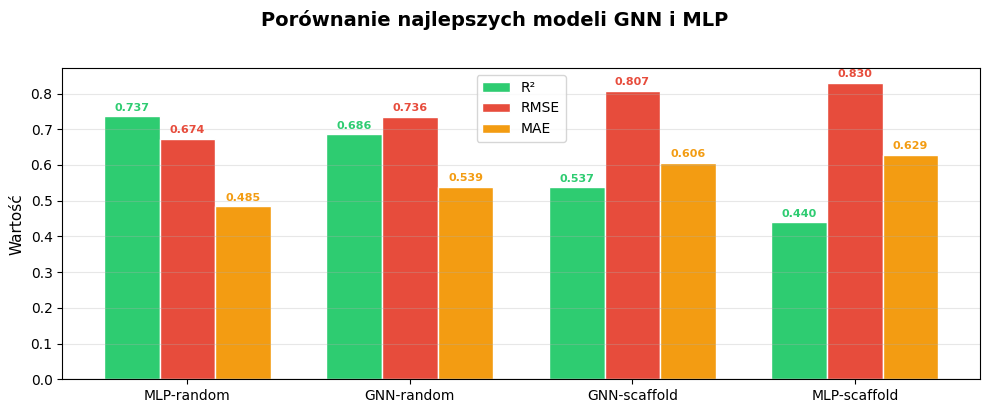

model,split,r2_val,rmse_val,mae_val,best_val_loss,best_epoch,epochs_trained,lr,batch_size
str,str,f64,f64,f64,f64,i64,i64,f64,i64
"""MLP""","""random""",0.736695,0.673666,0.484596,0.200562,57,72,0.0003,64
"""GNN""","""random""",0.686018,0.735643,0.539089,0.236669,128,140,0.0003,64
"""GNN""","""scaffold""",0.53724,0.807183,0.605754,0.279814,61,76,0.00025,64
"""MLP""","""scaffold""",0.439591,0.829953,0.629124,0.272446,28,43,0.0003,64


In [11]:
import matplotlib.pyplot as plt
import numpy as np

if results_table:
    df_all = pl.DataFrame(results_table)
    df_best = (
        df_all
        .group_by("model", "split")
        .agg(pl.all().sort_by("r2_val", descending=True).first())
        .sort("r2_val", descending=True)
    )

    labels = [f"{r['model']}-{r['split']}" for r in df_best.iter_rows(named=True)]
    x = np.arange(len(labels))
    width = 0.25

    r2 = df_best["r2_val"].to_list()
    rmse = df_best["rmse_val"].to_list()
    mae = df_best["mae_val"].to_list()

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle(
        "Porównanie najlepszych modeli GNN i MLP",
        fontsize=14, fontweight="bold", y=1.02,
    )

    bars1 = ax.bar(x - width, r2, width, label="R²",
                   color="#2ecc71", edgecolor="white")
    bars2 = ax.bar(x, rmse, width, label="RMSE",
                   color="#e74c3c", edgecolor="white")
    bars3 = ax.bar(x + width, mae, width, label="MAE",
                   color="#f39c12", edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Wartość", fontsize=11)
    ax.legend(fontsize=10)
    ax.axhline(y=0, color="gray", linewidth=0.8)
    ax.grid(axis="y", alpha=0.3)

    for bar, color in zip(bars1, ["#2ecc71"] * len(bars1)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=8, color=color, fontweight="bold")
    for bar, color in zip(bars2, ["#e74c3c"] * len(bars2)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=8, color=color, fontweight="bold")
    for bar, color in zip(bars3, ["#f39c12"] * len(bars3)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=8, color=color, fontweight="bold")

    plt.tight_layout()
    plt.show()

    COLS_SHOW = ["model", "split", "r2_val", "rmse_val",
                 "mae_val", "best_val_loss", "best_epoch",
                 "epochs_trained", "lr", "batch_size"]
    display(df_best.select(COLS_SHOW))
else:
    print("Brak wyników. Uruchom najpierw komórki treningowe.")

## MLP z deskryptorami molekularnymi + MACCS + BatchNorm

In [12]:
DESCRIPTOR_COLS = ["mw_freebase", "alogp", "hba", "hbd", "psa", "rtb", "aromatic_rings", "qed_weighted"]

MLP_ENHANCED_SPECS = [
    {"model_type": "MLP", "split_type": "random",   "df_fp": df_clean, "log_mlflow": True, "evaluate_test": False,
     "mlp_descriptor_cols": DESCRIPTOR_COLS, "mlp_use_maccs": True, "mlp_use_batch_norm": True},
    {"model_type": "MLP", "split_type": "scaffold", "df_fp": df_clean, "log_mlflow": True, "evaluate_test": False,
     "mlp_descriptor_cols": DESCRIPTOR_COLS, "mlp_use_maccs": True, "mlp_use_batch_norm": True},
]
mlp_enhanced_results = run_parallel_trainings(MLP_ENHANCED_SPECS, max_workers=2)

Loaded cached model: default_bd0a05c61761a368.pt | val R²=0.758 RMSE=0.646 MAE=0.463
Loaded cached model: default_5f2d3eeae6aa8cf4.pt | val R²=0.555 RMSE=0.776 MAE=0.576


In [13]:
if results_table:
    df_mlp_enh = pl.DataFrame(results_table).filter(pl.col("model") == "MLP")
    display(df_mlp_enh.select(SUMMARY_COLS).sort("r2_val", descending=True))
else:
    print("Brak wynikow.")

model,split,seed,lr,batch_size,weight_decay,avg_train_loss,avg_val_loss,best_val_loss,r2_val,rmse_val,mae_val,from_cache
str,str,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,bool
"""MLP""","""random""",42,0.0003,64,0.00001,0.246651,0.229419,0.185202,0.757982,0.64586,0.462955,true
"""MLP""","""random""",42,0.0003,64,0.00001,0.175852,0.220448,0.200562,0.736695,0.673666,0.484596,true
"""MLP""","""scaffold""",42,0.0003,64,0.00001,0.353796,0.382972,0.303026,0.555359,0.775838,0.576017,true
"""MLP""","""scaffold""",42,0.0003,64,0.00001,0.204489,0.308473,0.272446,0.439591,0.829953,0.629124,true


## Modele per-target (osobno dla EGFR i p38α)

In [14]:
TARGET_IDS = ["CHEMBL220", "CHEMBL4822"]
TARGET_NAMES = {"CHEMBL220": "EGFR", "CHEMBL4822": "p38α (MAPK14)"}

for target_id in TARGET_IDS:
    df_target = df_clean.filter(pl.col("target_chembl_id") == target_id)
    print(f"\n=== {target_id} ({TARGET_NAMES[target_id]}) | n={len(df_target)} ===\n")
    specs = [
        {"model_type": "MLP", "split_type": "random",   "df_fp": df_target, "log_mlflow": True, "evaluate_test": False},
        {"model_type": "MLP", "split_type": "scaffold", "df_fp": df_target, "log_mlflow": True, "evaluate_test": False},
        {"model_type": "GNN", "split_type": "random",   "df_fp": df_target, "log_mlflow": True, "evaluate_test": False, "epochs": 200},
        {"model_type": "GNN", "split_type": "scaffold", "df_fp": df_target, "log_mlflow": True, "evaluate_test": False, "epochs": 200},
    ]
    run_parallel_trainings(specs, max_workers=2)


=== CHEMBL220 (EGFR) | n=5935 ===

Loaded cached model: default_24f398a6208703eb.pt | val R²=0.771 RMSE=0.641 MAE=0.449
Loaded cached model: default_e7f7c0a0effd139b.pt | val R²=0.437 RMSE=0.895 MAE=0.599
Loaded cached model: default_79c92c30d0ae75fd.pt | val R²=0.585 RMSE=0.863 MAE=0.637
Loaded cached model: default_f7bc699c19699c6c.pt | val R²=0.220 RMSE=1.023 MAE=0.758

=== CHEMBL4822 (p38α (MAPK14)) | n=9788 ===

Loaded cached model: default_24f398a6208703eb.pt | val R²=0.698 RMSE=0.678 MAE=0.492
Loaded cached model: default_e7f7c0a0effd139b.pt | val R²=0.391 RMSE=0.873 MAE=0.658
Loaded cached model: default_79c92c30d0ae75fd.pt | val R²=0.653 RMSE=0.726 MAE=0.539
Loaded cached model: default_f7bc699c19699c6c.pt | val R²=0.294 RMSE=0.927 MAE=0.693


## Ensemble po seedach (3-5 seedów dla stabilniejszej oceny)

In [15]:
ENSEMBLE_SEEDS = [42, 123, 7, 99]

ensemble_specs = []
for seed in ENSEMBLE_SEEDS:
    for split in ["random", "scaffold"]:
        for model_type in ["MLP", "GNN"]:
            ensemble_specs.append({
                "model_type": model_type, "split_type": split, "df_fp": df_clean,
                "seed": seed, "log_mlflow": True, "evaluate_test": False,
            })

if results_table:
    df_existing = pl.DataFrame(results_table)
    missing = []
    for spec in ensemble_specs:
        exists = df_existing.filter(
            (pl.col("model") == spec["model_type"])
            & (pl.col("split") == spec["split_type"])
            & (pl.col("seed") == spec["seed"])
        ).height > 0
        if not exists:
            missing.append(spec)
    if missing:
        run_parallel_trainings(missing, max_workers=2)
    else:
        print("Wszystkie kombinacje seed x split x model juz istnieją w cache.")

# Podsumowanie ensemble
df_ens = pl.DataFrame(results_table).filter(pl.col("seed").is_in(ENSEMBLE_SEEDS))
summary = (
    df_ens.group_by("model", "split")
    .agg([
        pl.col("r2_val").mean().alias("r2_val_mean"),
        pl.col("r2_val").std().alias("r2_val_std"),
        pl.col("rmse_val").mean().alias("rmse_val_mean"),
        pl.col("rmse_val").std().alias("rmse_val_std"),
        pl.col("mae_val").mean().alias("mae_val_mean"),
        pl.col("mae_val").std().alias("mae_val_std"),
        pl.col("r2_val").count().alias("n_seeds"),
    ])
    .sort("r2_val_mean", descending=True)
)
print("\nEnsemble summary (mean ± std across seeds):")
display(summary)

Loaded cached model: default_533ce99678c46830.pt | val R²=0.737 RMSE=0.674 MAE=0.487
Loaded cached model: default_8f1303a92ca4781c.pt | val R²=0.419 RMSE=0.836 MAE=0.616
Loaded cached model: default_5b00309649ef4eb3.pt | val R²=0.736 RMSE=0.675 MAE=0.492
Loaded cached model: default_b70234d7a16b15b6.pt | val R²=0.652 RMSE=0.775 MAE=0.572
Loaded cached model: default_e15d840f99fc281c.pt | val R²=0.427 RMSE=0.832 MAE=0.620
Loaded cached model: default_26ba63eda430dcc6.pt | val R²=0.657 RMSE=0.769 MAE=0.570
Loaded cached model: default_5077c7e5502a0e1e.pt | val R²=0.738 RMSE=0.672 MAE=0.485
Loaded cached model: default_7456e35c7f9b3362.pt | val R²=0.434 RMSE=0.853 MAE=0.641
Loaded cached model: default_800a889cfa0f0097.pt | val R²=0.439 RMSE=0.866 MAE=0.634
Loaded cached model: default_286696e4d233c198.pt | val R²=0.638 RMSE=0.790 MAE=0.582
Loaded cached model: default_bd90f7f917881ded.pt | val R²=0.455 RMSE=0.856 MAE=0.642

Ensemble summary (mean ± std across seeds):


model,split,r2_val_mean,r2_val_std,rmse_val_mean,rmse_val_std,mae_val_mean,mae_val_std,n_seeds
str,str,f64,f64,f64,f64,f64,f64,u32
"""MLP""","""random""",0.739116,0.022773,0.665607,0.015228,0.478932,0.016459,7
"""GNN""","""random""",0.64517,0.033534,0.7764,0.048888,0.573017,0.03598,6
"""MLP""","""scaffold""",0.443947,0.052058,0.843878,0.038709,0.61885,0.026177,7
"""GNN""","""scaffold""",0.394446,0.064859,0.875332,0.043297,0.653445,0.031799,149


## Porównanie wszystkich wariantów

In [16]:
# Finalna tabela porównawcza
if results_table:
    df_final = pl.DataFrame(results_table)
    # Wez najlepszy wynik per (model, split) ignorujac seed
    df_best_per_config = (
        df_final
        .group_by("model", "split")
        .agg(pl.all().sort_by("r2_val", descending=True).first())
        .sort("r2_val", descending=True)
    )
    PREFERRED_COLS = [
        "model", "split", "seed", "r2_val", "rmse_val", "mae_val",
        "best_val_loss", "best_epoch", "epochs_trained", "lr", "batch_size",
    ]
    cols = [c for c in PREFERRED_COLS if c in df_best_per_config.columns]
    display(df_best_per_config.select(cols))
else:
    print("Brak wyników.")

model,split,seed,r2_val,rmse_val,mae_val,best_val_loss,best_epoch,epochs_trained,lr,batch_size
str,str,i64,f64,f64,f64,f64,i64,i64,f64,i64
"""MLP""","""random""",42,0.770834,0.64129,0.448941,0.200562,57,72,0.0003,64
"""GNN""","""random""",42,0.686018,0.735643,0.539089,0.236669,128,140,0.0003,64
"""MLP""","""scaffold""",42,0.555359,0.775838,0.576017,0.303026,23,38,0.0003,64
"""GNN""","""scaffold""",42,0.53724,0.807183,0.605754,0.279814,61,76,0.00025,64


## Uruchamianie z CLI (alternatywa dla notebooka)

Notebook jest dobry do eksploracji, ale do produkcji / dlugich treningow lepiej uzyc CLI:

```bash
# pojedynczy trening
python scripts/train.py train --model MLP --split random

# MLP z deskryptorami + MACCS + BatchNorm
python scripts/train.py train --model MLP --split scaffold --use-descriptors --use-maccs --batch-norm

# wszystkie kombinacje
python scripts/train.py train-all --use-descriptors --use-maccs --batch-norm

# tuning GNN z Optuna (wznawialny po przerwaniu!)
python scripts/train.py tune --split scaffold --n-trials 50

# podsumowanie studium Optuna
python scripts/train.py study-summary gnn_scaffold

# kampania z pliku YAML
python scripts/train.py campaign experiments/example_campaign.yaml
```

**Zalety CLI:**
- Mozna uruchamiac na serwerze / w tle (`nohup`, `screen`, `tmux`)
- Optuna zapisuje postep do SQLite — mozna przerwac i wznowic
- Grid search zastapiony Bayesian optimization (TPE) — mniej prob, lepsze wyniki
- Campaign YAML pozwala odtworzyc eksperymenty
- Brak ryzyka utraty stanu przez przypadkowe zamkniecie przegladarki
